# Результаты

Кривые обучения, метрики на валидации, что модель предсказывает на тесте и где ошибается, скорость.

In [1]:
import os, sys, json
sys.path.insert(0, '..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.common import Pack, read_image, rotate180, to_model_input
from src.evaluate import metrics, sigmoid
from src.predict import load_predictor, predict_logits

RUNS = ['w05', 'base_w1']   # w0.5 это та же сеть но в 2 раза уже
hist = {r: json.load(open(f'../runs/{r}/history.json')) for r in RUNS}

## Кривые обучения

`synth_val` это синтетика с незнакомыми шрифтами и текстами, `real_all` все реальные валидационные кропы вместе.

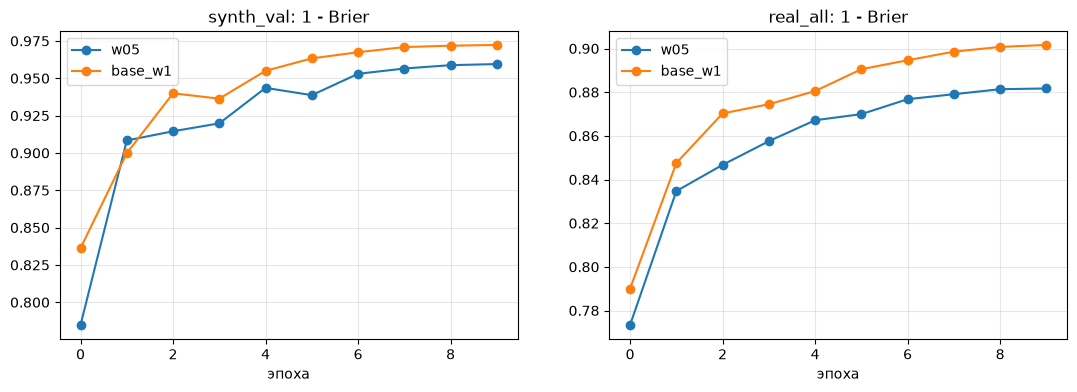

In [2]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for r in RUNS:
    h = hist[r]
    ax[0].plot([e['synth_val']['score'] for e in h], marker='o', label=r)
    ax[1].plot([e['real_all']['score'] for e in h], marker='o', label=r)
ax[0].set_title('synth_val: 1 - Brier'); ax[1].set_title('real_all: 1 - Brier')
for a in ax:
    a.set_xlabel('эпоха'); a.grid(alpha=0.3); a.legend()
plt.show()

In [3]:
rows = []
for r in RUNS:
    best = max(hist[r], key=lambda e: e['select'])
    row = {'run': r, 'эпоха': best['epoch'], 'synth_val': best['synth_val']['score'], 'real_all': best['real_all']['score']}
    for k in ['coco_val', 'ic15_val', 'textocr_val', 'hw_ru_val', 'plates_ru_val']:
        row[k] = best[k]['score']
    row['real_acc'] = best['real_all']['acc']
    rows.append(row)
pd.DataFrame(rows).set_index('run').round(4)

,эпоха,synth_val,real_all,coco_val,ic15_val,textocr_val,hw_ru_val,plates_ru_val,real_acc
run,,,,,,,,,
w05,9,0.9595,0.8817,0.8911,0.9008,0.8681,0.9561,0.9845,0.8191
base_w1,9,0.9723,0.9016,0.9057,0.9239,0.8920,0.9673,0.9938,0.8517


## Финальная модель (weights/model.onnx) на валидации

In [4]:
VAL = {'synth_val': '../data/synth/val.npz', 'coco_val': '../data/real/coco_val.npz', 'ic15_val': '../data/real/ic15_val.npz',
       'textocr_val': '../data/real/textocr_val.npz', 'hw_ru_val': '../data/real/hw_ru_val.npz', 'plates_ru_val': '../data/real/plates_ru_val.npz'}

def rotated_set(pack, seed=1):
    # так же как в src/data.py: примерно половину поворачиваем, метка = был ли поворот
    rot = np.random.RandomState(seed).rand(len(pack)) < 0.5
    return [rotate180(pack[i]) if r else pack[i] for i, r in enumerate(rot)], rot.astype(float)

final = load_predictor('../weights/model.onnx')
val = {k: rotated_set(Pack(v)) for k, v in VAL.items()}
val_p = {k: sigmoid(predict_logits(final, np.stack([to_model_input(a, 256) for a in arrs]))) for k, (arrs, y) in val.items()}

rows = {k: metrics(val[k][1], val_p[k]) for k in VAL}
y_real = np.concatenate([val[k][1] for k in VAL if k != 'synth_val'])
p_real = np.concatenate([val_p[k] for k in VAL if k != 'synth_val'])
rows['real_all'] = metrics(y_real, p_real)
pd.DataFrame(rows).T[['score', 'acc', 'logloss', 'ece']].round(4)

,score,acc,logloss,ece
synth_val,0.9723,0.9616,0.0965,0.0195
coco_val,0.9057,0.8575,0.2964,0.0147
ic15_val,0.9239,0.8886,0.2467,0.0353
textocr_val,0.8920,0.8366,0.3363,0.0135
hw_ru_val,0.9673,0.9612,0.1320,0.0291
plates_ru_val,0.9938,0.9933,0.0342,0.0261
real_all,0.9016,0.8517,0.3085,0.0114


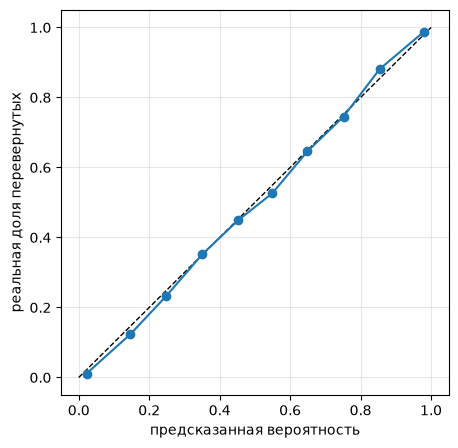

In [5]:
# насколько вероятностям можно верить: предсказанная вероятность vs реальная доля перевернутых
y_all = np.concatenate([val[k][1] for k in VAL])
p_all = np.concatenate([val_p[k] for k in VAL])
edges = np.linspace(0, 1, 11)
idx = np.clip(np.digitize(p_all, edges) - 1, 0, 9)
xs = [p_all[idx == b].mean() for b in range(10) if (idx == b).sum() > 20]
ys = [y_all[idx == b].mean() for b in range(10) if (idx == b).sum() > 20]
plt.figure(figsize=(5, 5))
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.plot(xs, ys, marker='o')
plt.xlabel('предсказанная вероятность'); plt.ylabel('реальная доля перевернутых'); plt.grid(alpha=0.3)
plt.show()

Почти по диагонали, то есть вероятности нормальные и без отдельной калибровки (label smoothing при обучении тут видимо помогает).

In [6]:
# качество в зависимости от ширины картинки (примерно = длина текста)
arrs_real = sum([val[k][0] for k in VAL if k != 'synth_val'], [])
w = np.array([a.shape[1] for a in arrs_real])
rows = []
for lo, hi in [(0, 48), (48, 80), (80, 128), (128, 256), (256, 1000)]:
    m = (w >= lo) & (w < hi)
    rows.append({'ширина': f'{lo}-{hi}', 'картинок': m.sum(), 'score': metrics(y_real[m], p_real[m])['score']})
pd.DataFrame(rows).round(4)

,ширина,картинок,score
0,0-48,5114,0.8246
1,48-80,10277,0.8937
2,80-128,7008,0.9388
3,128-256,3122,0.9662
4,256-1000,222,0.9593


Короткие картинки (1-3 символа) сильно сложнее, на длинных строках модель почти не ошибается.

## Что модель говорит на тесте

Меток нет, поэтому смотрим только на распределение вероятностей и глазами на примеры.

картинок: 20000
среднее p_180: 0.5012  доля p > 0.5: 0.5022
неуверенных (0.1 < p < 0.9): 0.1924


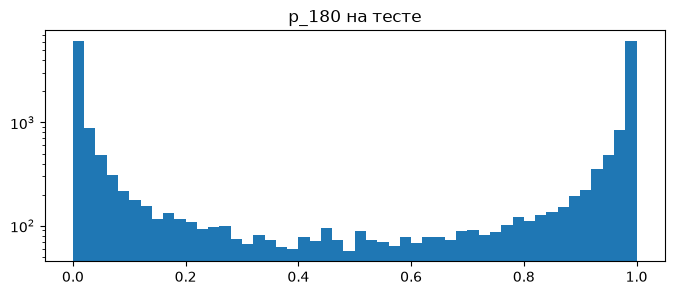

In [7]:
sub = pd.read_csv('../submission.csv')
p = sub.p_180.values
print('картинок:', len(sub))
print('среднее p_180:', p.mean().round(4), ' доля p > 0.5:', (p > 0.5).mean().round(4))
print('неуверенных (0.1 < p < 0.9):', ((p > 0.1) & (p < 0.9)).mean().round(4))
plt.figure(figsize=(8, 3))
plt.hist(p, bins=50); plt.yscale('log'); plt.title('p_180 на тесте'); plt.show()

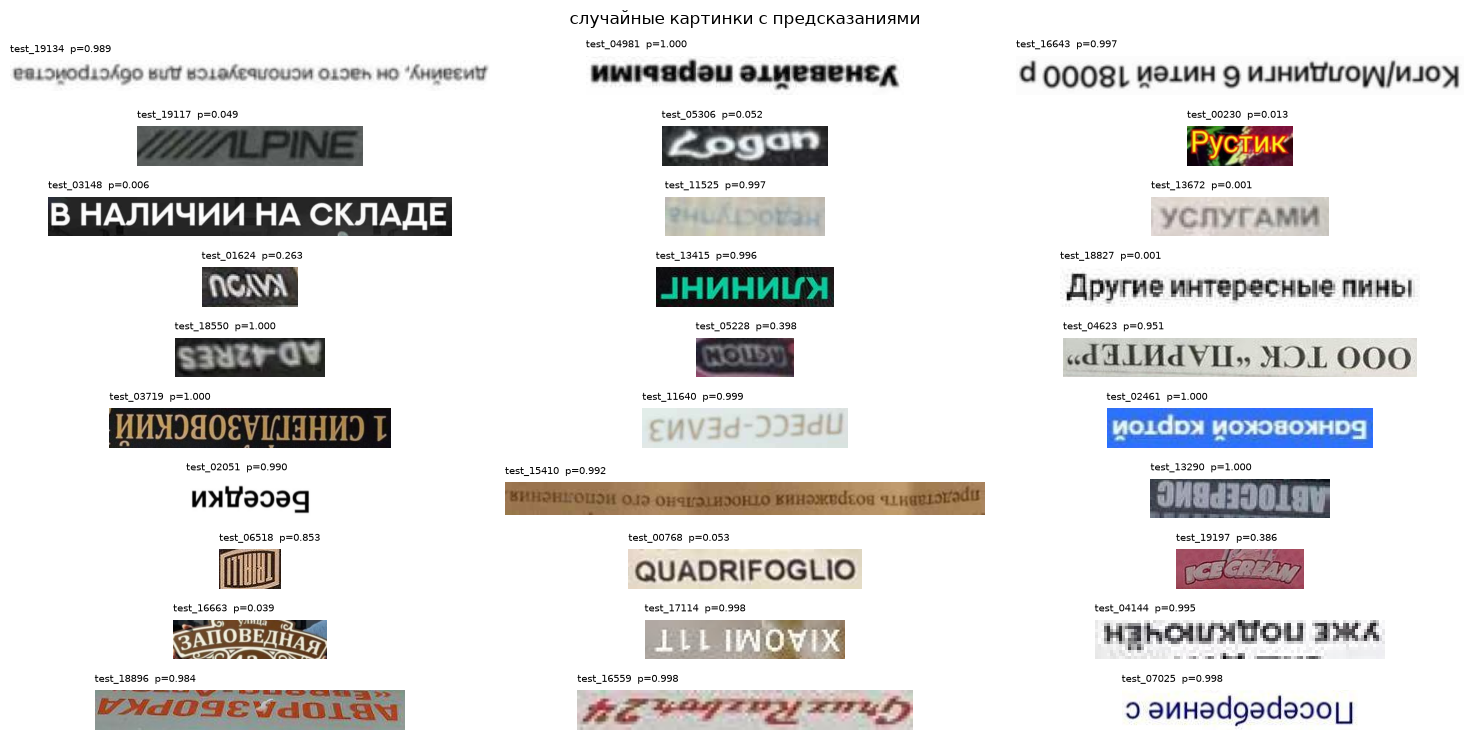

In [8]:
def show_test(ids, title, ncols=3):
    nrows = int(np.ceil(len(ids) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 0.75 * nrows))
    for ax in axes.ravel():
        ax.axis('off')
    pmap = dict(zip(sub.image_id, sub.p_180))
    for ax, i in zip(axes.ravel(), ids):
        ax.imshow(read_image(f'../data/test/images/{i}.png')[:, :, ::-1])
        ax.set_title(f'{i}  p={pmap[i]:.3f}', fontsize=7, loc='left')
    fig.suptitle(title); plt.tight_layout(); plt.show()

rng = np.random.RandomState(0)
show_test(rng.choice(sub.image_id.values, 30, replace=False).tolist(), 'случайные картинки с предсказаниями')

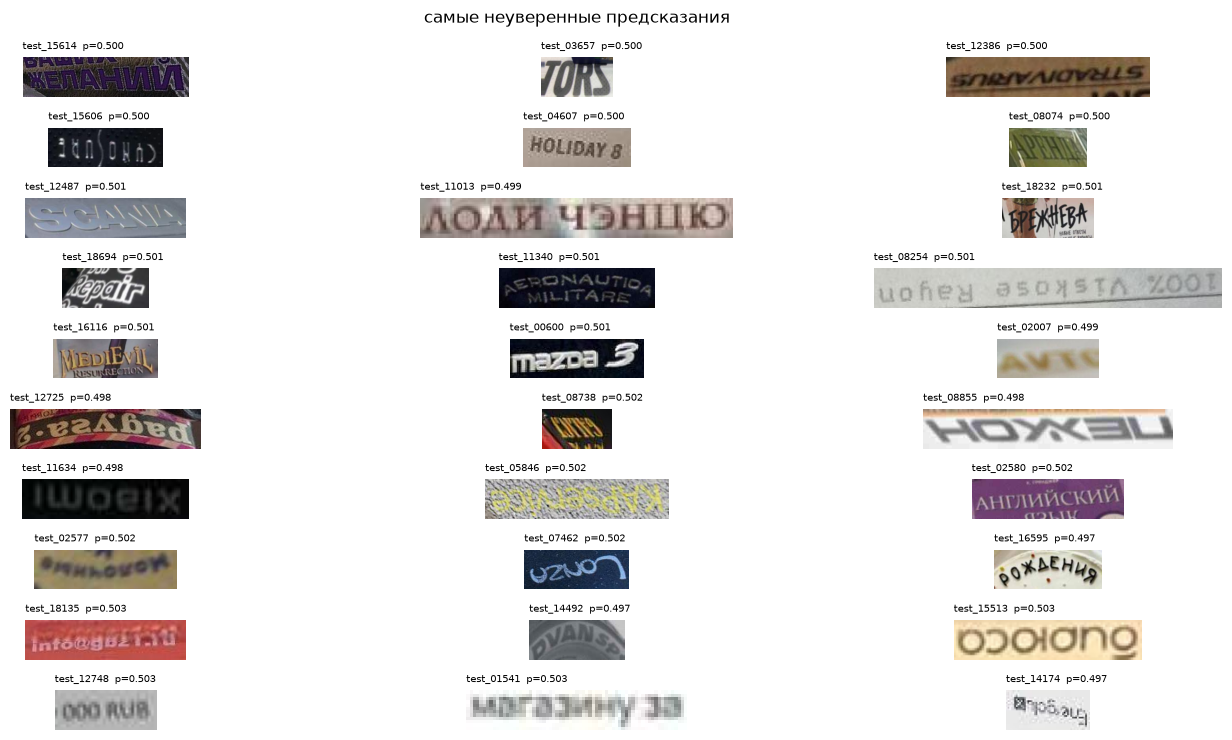

In [9]:
unsure = sub.iloc[np.argsort(np.abs(sub.p_180.values - 0.5))[:30]].image_id.tolist()
show_test(unsure, 'самые неуверенные предсказания')

## Ошибки на реальной валидации

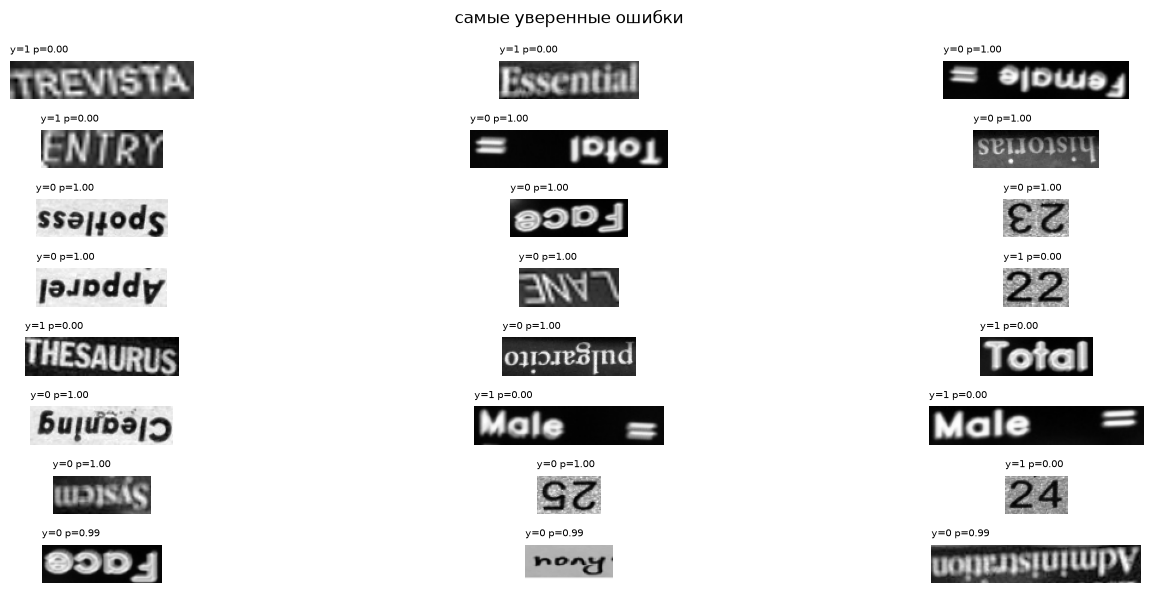

In [10]:
err = np.where((p_real > 0.5) != (y_real > 0.5))[0]
worst = err[np.argsort(-np.abs(p_real[err] - 0.5))][:24]
fig, axes = plt.subplots(8, 3, figsize=(15, 6))
for ax in axes.ravel():
    ax.axis('off')
for ax, i in zip(axes.ravel(), worst):
    ax.imshow(arrs_real[i], cmap='gray'); ax.set_title(f'y={int(y_real[i])} p={p_real[i]:.2f}', fontsize=7, loc='left')
fig.suptitle('самые уверенные ошибки'); plt.tight_layout(); plt.show()

## Скорость

onnxruntime, одно ядро cpu, замер в `src/export.py`.

In [11]:
rows = []
for name, f in [('w0.5', '../runs/w05/model_info.json'), ('w1.0 (финал)', '../weights/model_info.json')]:
    d = json.load(open(f)); d['модель'] = name
    rows.append(d)
pd.DataFrame(rows).set_index('модель').round(3)

,params,size_kb,ms_per_box_bs1,ms_per_box_bs64
модель,,,,
w0.5,68601,271.614,0.504,0.407
w1.0 (финал),273137,1069.621,1.100,0.965


## Выводы

* w1.0 заметно лучше w0.5 (+0.013 на синтетике, +0.02 на реальных) и все еще быстрая, около 1 мс на бокс на одном ядре.
* Вероятности и так нормально откалиброваны.
* Самое сложное: короткие боксы из 1-3 символов и стилизованные логотипы.
* Длинные строки сейчас просто сжимаются до 256 пикселей по ширине, для очень длинных это наверно не очень хорошо,
  можно было бы резать их на куски.